<a href="https://colab.research.google.com/github/jimalike/muaythai-pose-estimation/blob/main/Muay_V13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import os

# เชื่อมต่อ Google Drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
# =============================================================================
# 📁 FILE: train_v13_hybrid_mha_fixed.py
# 🏆 LEVEL: HYBRID MHA (CNN + LSTM + Multi-Head Attention)
# 🔧 STATUS: FIXED (แก้ Error: SparseCategoricalCrossentropy ไม่รับ label_smoothing เรียบร้อย)
# =============================================================================

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import (Layer, LSTM, Dense, Dropout, BatchNormalization,
                                     Bidirectional, Input, Conv1D, GlobalAveragePooling1D,
                                     MultiHeadAttention, LayerNormalization, Add)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical # 🔥 ต้องมีตัวนี้เพื่อแก้ Error
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math

# --- CONFIG ---
CSV_PATH = '/content/drive/MyDrive/Vision/ProjectMuay/pose_timeseries_labeled_v2.csv'
MODEL_SAVE_NAME = 'muaythai_v13_hybrid_mha.h5'
WINDOW_SIZE = 60

# ================= 1. Feature Extraction (V11 Standard) =================
def calculate_angle_numpy(a, b, c):
    ba = a - b; bc = c - b
    cosine_angle = np.sum(ba * bc, axis=1) / (np.linalg.norm(ba, axis=1) * np.linalg.norm(bc, axis=1) + 1e-6)
    angle = np.arccos(np.clip(cosine_angle, -1.0, 1.0))
    return np.degrees(angle) / 180.0

def extract_features_v11(df):
    data = df.copy()
    print("🧬 Extracting Features V11...")
    keypoints = ['nose', 'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
                 'left_wrist', 'right_wrist', 'left_hip', 'right_hip', 'left_knee',
                 'right_knee', 'left_ankle', 'right_ankle']

    for kp in keypoints:
        for axis in ['x', 'y']:
            col = f'{kp}_{axis}'
            data[col] = data.groupby('person_id')[col].transform(lambda x: x.replace(0, np.nan).interpolate().fillna(0))
            data[col] = data.groupby('person_id')[col].transform(lambda x: savgol_filter(x, 5, 2) if len(x) > 5 else x)

    data['torso_len'] = np.sqrt(((data.left_shoulder_x + data.right_shoulder_x)/2 - (data.left_hip_x + data.right_hip_x)/2)**2 +
                                ((data.left_shoulder_y + data.right_shoulder_y)/2 - (data.left_hip_y + data.right_hip_y)/2)**2)
    person_scale = data.groupby('person_id')['torso_len'].median()
    data['stable_scale'] = data['person_id'].map(person_scale).replace(0, 0.001)
    mid_hip_x = (data.left_hip_x + data.right_hip_x) / 2
    mid_hip_y = (data.left_hip_y + data.right_hip_y) / 2
    feature_cols = []

    for kp in keypoints:
        data[f'{kp}_x_n'] = (data[f'{kp}_x'] - mid_hip_x) / data['stable_scale']
        data[f'{kp}_y_n'] = (data[f'{kp}_y'] - mid_hip_y) / data['stable_scale']
        feature_cols.extend([f'{kp}_x_n', f'{kp}_y_n'])
        dx = data.groupby('person_id')[f'{kp}_x_n'].diff().fillna(0)
        dy = data.groupby('person_id')[f'{kp}_y_n'].diff().fillna(0)
        data[f'{kp}_v_n'] = np.sqrt(dx**2 + dy**2)
        feature_cols.append(f'{kp}_v_n')

    def get_points(p_name): return data[[f'{p_name}_x', f'{p_name}_y']].values
    data['angle_l_elbow'] = calculate_angle_numpy(get_points('left_shoulder'), get_points('left_elbow'), get_points('left_wrist'))
    data['angle_r_elbow'] = calculate_angle_numpy(get_points('right_shoulder'), get_points('right_elbow'), get_points('right_wrist'))
    data['angle_sh_lift_l'] = calculate_angle_numpy(get_points('left_hip'), get_points('left_shoulder'), get_points('left_elbow'))
    data['angle_sh_lift_r'] = calculate_angle_numpy(get_points('right_hip'), get_points('right_shoulder'), get_points('right_elbow'))
    data['angle_l_knee'] = calculate_angle_numpy(get_points('left_hip'), get_points('left_knee'), get_points('left_ankle'))
    data['angle_r_knee'] = calculate_angle_numpy(get_points('right_hip'), get_points('right_knee'), get_points('right_ankle'))
    data['angle_l_hip_open'] = calculate_angle_numpy(get_points('left_shoulder'), get_points('left_hip'), get_points('left_knee'))
    data['angle_r_hip_open'] = calculate_angle_numpy(get_points('right_shoulder'), get_points('right_hip'), get_points('right_knee'))
    curr_sh_width = np.sqrt((data.left_shoulder_x - data.right_shoulder_x)**2 + (data.left_shoulder_y - data.right_shoulder_y)**2)
    data['body_rotation_ratio'] = curr_sh_width / data['stable_scale']
    data['wrist_dist_n'] = np.sqrt((data.left_wrist_x - data.right_wrist_x)**2 + (data.left_wrist_y - data.right_wrist_y)**2) / data['stable_scale']

    feature_cols.extend([
        'angle_l_elbow', 'angle_r_elbow', 'angle_sh_lift_l', 'angle_sh_lift_r',
        'angle_l_knee', 'angle_r_knee', 'angle_l_hip_open', 'angle_r_hip_open',
        'body_rotation_ratio', 'wrist_dist_n'
    ])
    return data, feature_cols

# ================= 2. Augmentation =================
def augment_data_v13(X, y):
    print("🌪️ Augmenting with Time Warping...")
    X_aug, y_aug = [], []
    for i in range(len(X)):
        X_aug.append(X[i]); y_aug.append(y[i]) # Original

        noise = np.random.normal(0, 0.03, X[i].shape) # Noise
        X_aug.append(X[i] + noise); y_aug.append(y[i])

        scale = np.random.uniform(0.9, 1.1) # Scale
        X_aug.append(X[i] * scale); y_aug.append(y[i])

        # Time Warping
        speed_rate = np.random.uniform(0.8, 1.2)
        old_time = np.arange(len(X[i]))
        warped_sample = np.zeros_like(X[i])
        for feat in range(X[i].shape[1]):
            f = interp1d(old_time, X[i][:, feat], kind='linear', fill_value="extrapolate")
            warped_sample[:, feat] = f(np.linspace(0, len(X[i])-1, len(X[i])))
        X_aug.append(warped_sample); y_aug.append(y[i])

    return np.array(X_aug), np.array(y_aug)

# ================= 3. MODEL: HYBRID MHA (CNN + LSTM + Multi-Head Attn) =================
def create_hybrid_mha_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    reg = l2(0.001)

    # 1. CNN Feature Extractor
    x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    # 2. LSTM Sequence Modeling
    x = Bidirectional(LSTM(128, return_sequences=True, kernel_regularizer=reg))(x)
    x = BatchNormalization()(x); x = Dropout(0.4)(x)

    # 3. Multi-Head Attention (The "Transformer-like" part)
    attn_output = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    x = Add()([x, attn_output]) # Skip Connection
    x = LayerNormalization(epsilon=1e-6)(x)

    # 4. Global Average Pooling & Output
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.4)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

# ================= 4. Execution Flow (FIXED) =================
if not os.path.exists(CSV_PATH):
    print(f"❌ Error: File not found at {CSV_PATH}")
else:
    print(f"📂 Found file: {CSV_PATH}")
    df = pd.read_csv(CSV_PATH)
    df_feat, FEATURE_COLS = extract_features_v11(df)

    TRAIN_IDS = [1, 3, 4, 7, 8]
    le = LabelEncoder()
    df_feat['target'] = le.fit_transform(df_feat['action'])
    num_classes = len(le.classes_) # ✅ เก็บจำนวนคลาส

    X_train, y_train, X_test, y_test = [], [], [], []
    for pid in df_feat['person_id'].unique():
        grp = df_feat[df_feat['person_id'] == pid]
        if len(grp) < WINDOW_SIZE: continue
        vals = grp[FEATURE_COLS].values; lbls = grp['target'].values
        for i in range(WINDOW_SIZE, len(grp), 5):
            if pid in TRAIN_IDS:
                X_train.append(vals[i-WINDOW_SIZE:i]); y_train.append(lbls[i])
            else:
                X_test.append(vals[i-WINDOW_SIZE:i]); y_test.append(lbls[i])

    X_train, y_train = np.array(X_train), np.array(y_train)
    X_test, y_test = np.array(X_test), np.array(y_test)
    X_train_aug, y_train_aug = augment_data_v13(X_train, y_train)

    print(f"Train Shape: {X_train_aug.shape}")
    print(f"Test Shape: {X_test.shape}")

    # ⚖️ Class Weight (ใช้ y แบบ integer ปกติ)
    cw = dict(enumerate(class_weight.compute_class_weight('balanced', classes=np.unique(y_train_aug), y=y_train_aug)))

    # 🔥🔥 FIX: แปลงเป็น One-Hot Encoding ก่อนส่งเข้าเทรน 🔥🔥
    # เพราะ CategoricalCrossentropy ต้องการ One-Hot
    y_train_aug_onehot = to_categorical(y_train_aug, num_classes=num_classes)
    y_test_onehot = to_categorical(y_test, num_classes=num_classes)

    # Build Model
    model = create_hybrid_mha_model((WINDOW_SIZE, len(FEATURE_COLS)), num_classes)

    # 🔥🔥 FIX: ใช้ CategoricalCrossentropy (ตัดคำว่า Sparse ออก)
    # แบบนี้จะรองรับ label_smoothing=0.1 ได้แน่นอนครับ
    loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

    model.compile(optimizer=tf.keras.optimizers.Adam(0.0005), loss=loss_fn, metrics=['accuracy'])

    def cosine_decay(epoch):
        initial_lr = 0.0005
        min_lr = 0.00001
        epochs_per_cycle = 20
        cos_inner = (math.pi * (epoch % epochs_per_cycle)) / (epochs_per_cycle)
        return min_lr + (initial_lr - min_lr) / 2 * (math.cos(cos_inner) + 1)

    lrs = LearningRateScheduler(cosine_decay)
    es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
    cp = ModelCheckpoint(MODEL_SAVE_NAME, save_best_only=True, monitor='val_loss')

    print(f"🥊 Training V13 HYBRID MHA (CNN-LSTM-Attention)...")
    history = model.fit(
        X_train_aug, y_train_aug_onehot, # ✅ ส่งแบบ One-Hot
        validation_data=(X_test, y_test_onehot), # ✅ ส่งแบบ One-Hot
        epochs=100,
        batch_size=64,
        class_weight=cw,
        callbacks=[es, lrs, cp],
        verbose=1
    )
    print(f"✅ Training Complete. Model saved as: {MODEL_SAVE_NAME}")

    # Evaluation (แปลงกลับเป็น Index เพื่อทำ Report)
    y_pred = np.argmax(model.predict(X_test), axis=1)

    print("\n📝 Final Report (V13 Hybrid MHA):")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

📂 Found file: /content/drive/MyDrive/Vision/ProjectMuay/pose_timeseries_labeled_v2.csv
🧬 Extracting Features V11...
🌪️ Augmenting with Time Warping...
Train Shape: (15208, 60, 49)
Test Shape: (3001, 60, 49)
🥊 Training V13 HYBRID MHA (CNN-LSTM-Attention)...
Epoch 1/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7989 - loss: 1.1043

238/238 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.7993 - loss: 1.1035 - val_accuracy: 0.7867 - val_loss: 1.0971 - learning_rate: 5.0000e-04
Epoch 2/100
236/238 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9582 - loss: 0.7162

238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9583 - loss: 0.7159 - val_accuracy: 0.8854 - val_loss: 0.8471 - learning_rate: 4.9698e-04
Epoch 3/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9763 - loss: 0.6249 - val_accuracy: 0.8674 - val_loss: 0.9186 - learning_rate: 4.8801e-04
Epoch 4/100
236/238 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9799 - loss: 0.5840

238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9799 - loss: 0.5838 - val_accuracy: 0.8950 - val_loss: 0.7521 - learning_rate: 4.7330e-04
Epoch 5/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9836 - loss: 0.5479

238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9836 - loss: 0.5479 - val_accuracy: 0.9337 - val_loss: 0.6630 - learning_rate: 4.5321e-04
Epoch 6/100
237/238 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9858 - loss: 0.5296

238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9858 - loss: 0.5296 - val_accuracy: 0.9264 - val_loss: 0.6625 - learning_rate: 4.2824e-04
Epoch 7/100
237/238 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9847 - loss: 0.5220

238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9848 - loss: 0.5220 - val_accuracy: 0.9270 - val_loss: 0.6401 - learning_rate: 3.9901e-04
Epoch 8/100
236/238 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9885 - loss: 0.5002

238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9885 - loss: 0.5002 - val_accuracy: 0.9324 - val_loss: 0.6265 - learning_rate: 3.6623e-04
Epoch 9/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9906 - loss: 0.4894 - val_accuracy: 0.9184 - val_loss: 0.6438 - learning_rate: 3.3071e-04
Epoch 10/100
237/238 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9898 - loss: 0.4847

238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9898 - loss: 0.4847 - val_accuracy: 0.9404 - val_loss: 0.6000 - learning_rate: 2.9333e-04
Epoch 11/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9921 - loss: 0.4844 - val_accuracy: 0.9340 - val_loss: 0.6124 - learning_rate: 2.5500e-04
Epoch 12/100
236/238 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9933 - loss: 0.4751

238/238 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9933 - loss: 0.4751 - val_accuracy: 0.9474 - val_loss: 0.5919 - learning_rate: 2.1667e-04
Epoch 13/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9969 - loss: 0.4643 - val_accuracy: 0.9370 - val_loss: 0.6026 - learning_rate: 1.7929e-04
Epoch 14/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9958 - loss: 0.4647 - val_accuracy: 0.9314 - val_loss: 0.6213 - learning_rate: 1.4377e-04
Epoch 15/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9970 - loss: 0.4603 - val_accuracy: 0.9340 - val_loss: 0.6095 - learning_rate: 1.1099e-04
Epoch 16/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9975 - loss: 0.4581 - val_accuracy: 0.9380 - val_loss: 0.5991 - learning_rate: 8.1759e-05
Epoch 17/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9975 - loss: 0.4557 - val_accuracy: 0.9330 - val_loss: 0.6057 - learning_rate: 5.6791e-05
Epoch 18/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - ac


📊 Generating Graphs for V13...


/tmp/ipython-input-133282366.py:43: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-133282366.py:43: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


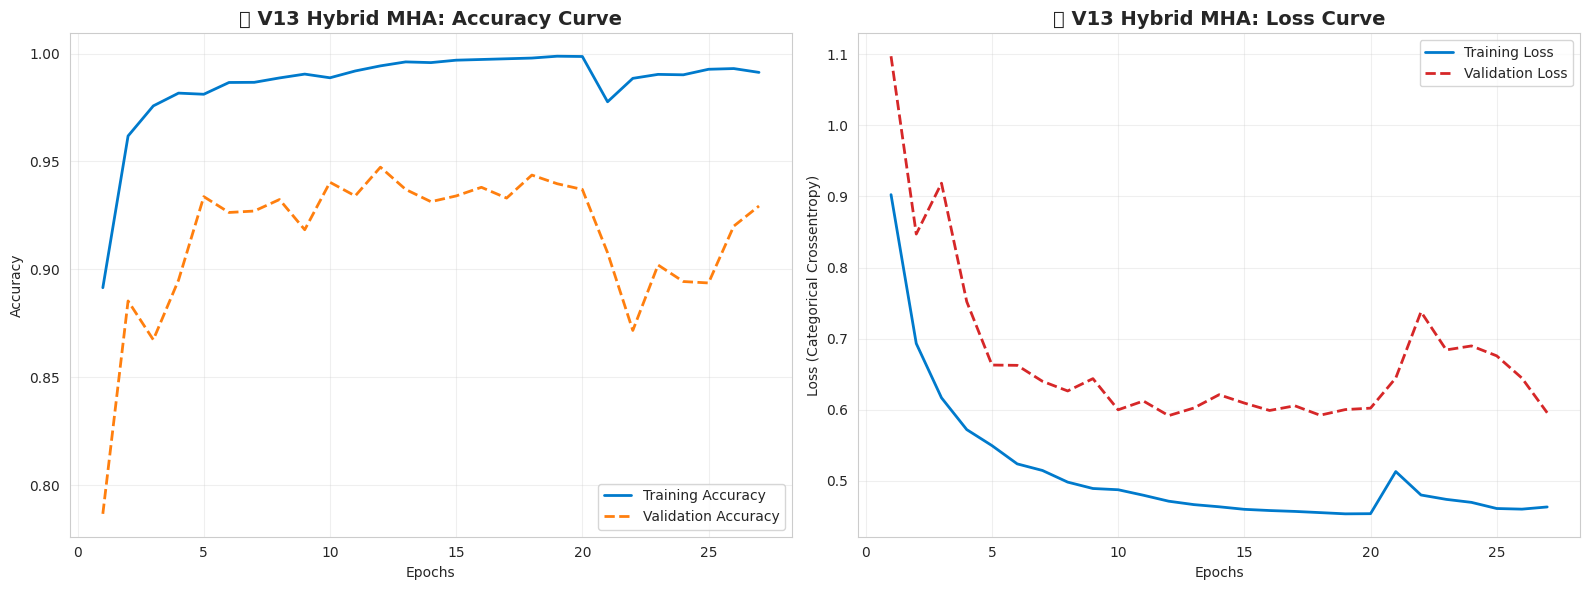

⏳ Testing V13 Model with 3001 samples...


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io,

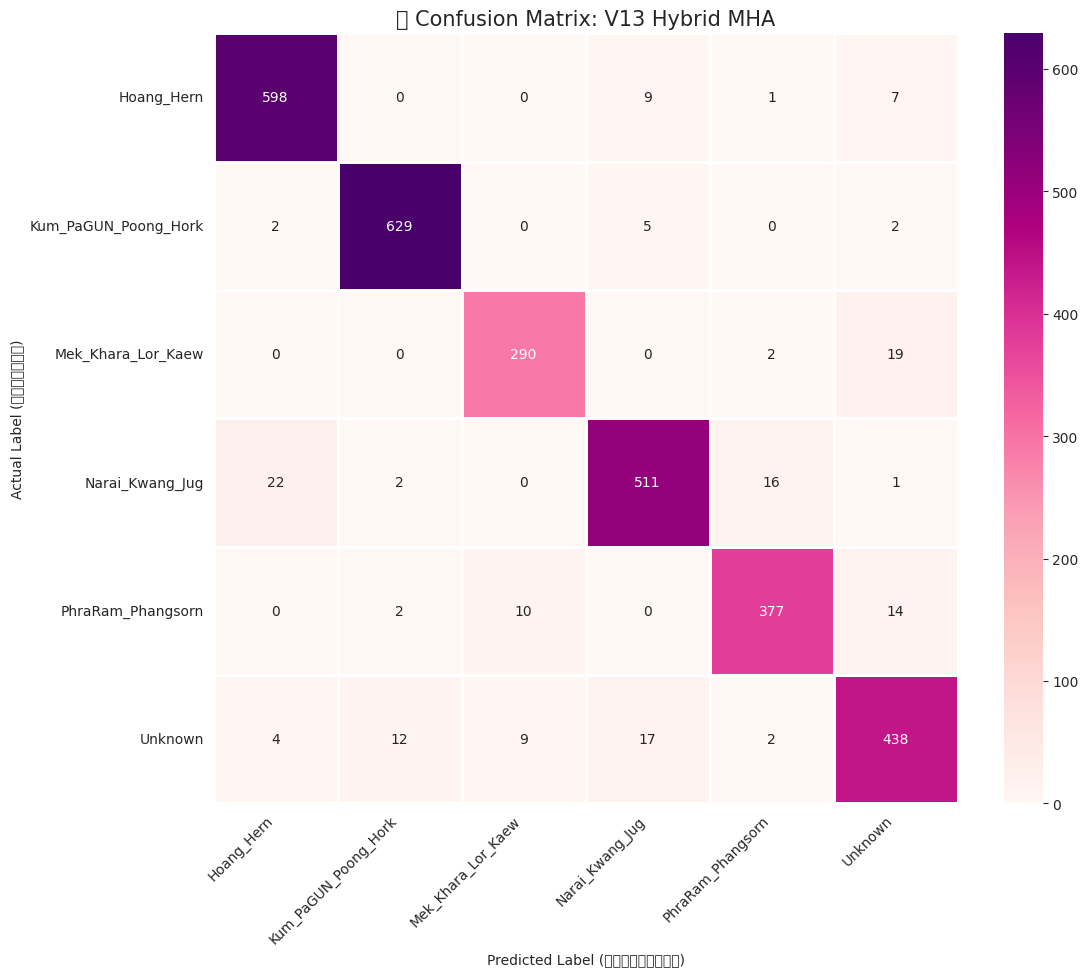


📝 DETAILED REPORT (V13):
                      precision    recall  f1-score   support

          Hoang_Hern       0.96      0.97      0.96       615
Kum_PaGUN_Poong_Hork       0.98      0.99      0.98       638
  Mek_Khara_Lor_Kaew       0.94      0.93      0.94       311
     Narai_Kwang_Jug       0.94      0.93      0.93       552
   PhraRam_Phangsorn       0.95      0.94      0.94       403
             Unknown       0.91      0.91      0.91       482

            accuracy                           0.95      3001
           macro avg       0.94      0.94      0.94      3001
        weighted avg       0.95      0.95      0.95      3001



In [ ]:
# =============================================================================
# 📊 VISUALIZATION TOOLS (V13 HYBRID MHA EDITION)
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# ตั้งค่า Design กราฟให้ดู Inter
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# --- 1. กราฟ Training History (V13 Style) ---
def plot_history_v13(history, model_name="V13 Hybrid MHA"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(16, 6))

    # 📈 กราฟ Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='#007acc', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', linewidth=2, linestyle='--')
    plt.title(f'🏆 {model_name}: Accuracy Curve', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # 📉 กราฟ Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='#007acc', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='#d62728', linewidth=2, linestyle='--')
    plt.title(f'📉 {model_name}: Loss Curve', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (Categorical Crossentropy)')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- 2. Confusion Matrix (Robust Version) ---
def plot_confusion_matrix_v13(model, X_test, y_true, classes):
    print(f"⏳ Testing V13 Model with {len(X_test)} samples...")

    # 1. Predict
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1) # แปลง Prob เป็น Index (0,1,2...)

    # 2. Handle Ground Truth (เผื่อส่งมาเป็น One-Hot หรือ Integer ก็รับได้หมด)
    if y_true.ndim > 1 and y_true.shape[1] > 1:
        y_true_indices = np.argmax(y_true, axis=1) # แปลง One-Hot กลับเป็น Index
    else:
        y_true_indices = y_true # เป็น Index อยู่แล้ว

    # 3. Create Matrix
    cm = confusion_matrix(y_true_indices, y_pred)

    # 4. Plot Heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', # สีโทนม่วง-แดง ดูล้ำๆ
                xticklabels=classes, yticklabels=classes,
                linewidths=1, linecolor='white')

    plt.title('🤖 Confusion Matrix: V13 Hybrid MHA', fontsize=15)
    plt.ylabel('Actual Label (ท่าจริง)')
    plt.xlabel('Predicted Label (ท่าที่ทาย)')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.show()

    # 5. Text Report
    print("\n📝 DETAILED REPORT (V13):")
    print(classification_report(y_true_indices, y_pred, target_names=classes))

# ==========================================
# ▶️ RUN VISUALIZATION
# ==========================================

print("\n📊 Generating Graphs for V13...")

# 1. เรียกดูกราฟเทรน (Loss/Acc)
if 'history' in globals():
    plot_history_v13(history)
else:
    print("⚠️ Warning: 'history' variable not found.")

# 2. เรียกดู Confusion Matrix
if 'model' in globals() and 'X_test' in globals():
    # ใช้ y_test (ที่เป็น Integer) หรือ y_test_onehot ก็ได้ ฟังก์ชันผมเขียนดักไว้ให้แล้ว
    plot_confusion_matrix_v13(model, X_test, y_test, le.classes_)
else:
    print("⚠️ Warning: 'model' or 'X_test' variable not found.")

เทส วิดีโอ


In [ ]:
# --- Cell 1: Install for GPU ---
import os
import sys

print("🔗 เชื่อมต่อ Drive...")
from google.colab import drive
drive.mount('/content/drive')

print("🧹 เคลียร์ Environment เก่า...")
!pip uninstall -y mediapipe protobuf ultralytics tensorflow

print("🚀 ติดตั้ง Library สายซิ่ง...")
!pip install ultralytics
!pip install pandas numpy opencv-python scipy
# TensorFlow ใน Colab ปกติรองรับ GPU อยู่แล้ว แค่ลงให้ชัวร์
!pip install tensorflow

print("✅ ติดตั้งเสร็จแล้ว! เช็ค GPU กันหน่อย...")
import tensorflow as tf
import torch
print(f"🧠 TensorFlow GPU: {tf.config.list_physical_devices('GPU')}")
print(f"🔥 PyTorch GPU: {torch.cuda.is_available()}")
print("ถ้าเห็นชื่อ GPU โผล่มา แปลว่าพร้อมซิ่งแล้วครับ! ไป Cell 2 ได้เลย")

In [ ]:
# =============================================================================
# 📁 FILE: inference_v13_pure_final.py
# 🏆 LEVEL: PURE AI (No Hard-coded Rules)
# ✨ FEATURES: Skeleton + Bold Text + High Precision
# =============================================================================

import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from ultralytics import YOLO
from collections import deque
from scipy.signal import savgol_filter
import os

# ================= 1. CONFIGURATION =================
PROJECT_FOLDER = '/content/drive/MyDrive/Vision/ProjectMuay'
VIDEO_FILENAME = 'muay_thai_1080p_clip.mp4'
MODEL_FILENAME = 'muaythai_v13_hybrid_mha.h5'
OUTPUT_FILENAME = 'output_v13_pure_final.mp4'

VIDEO_PATH = os.path.join(PROJECT_FOLDER, VIDEO_FILENAME)
MODEL_PATH = os.path.join(PROJECT_FOLDER, MODEL_FILENAME)
OUTPUT_PATH = os.path.join(PROJECT_FOLDER, OUTPUT_FILENAME)

YOLO_MODEL_NAME = 'yolo26x-pose.pt'
WINDOW_SIZE = 60
CLASSES = ['Hoang_Hern', 'Kum_PaGUN_Poong_Hork', 'Mek_Khara_Lor_Kaew',
           'Narai_Kwang_Jug', 'PhraRam_Phangsorn', 'Unknown']

CLASS_COLORS = {
    'Hoang_Hern': (0, 0, 255), 'Kum_PaGUN_Poong_Hork': (0, 255, 0),
    'Mek_Khara_Lor_Kaew': (255, 0, 255), 'Narai_Kwang_Jug': (0, 255, 255),
    'PhraRam_Phangsorn': (255, 128, 0), 'Unknown': (128, 128, 128),
    'Gathering...': (50, 50, 50)
}

SKELETON_CONNECTIONS = [
    (5, 7), (7, 9), (6, 8), (8, 10), (5, 6), (5, 11), (6, 12),
    (11, 12), (11, 13), (13, 15), (12, 14), (14, 16)
]
KEYPOINTS = ['nose', 'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
             'left_wrist', 'right_wrist', 'left_hip', 'right_hip', 'left_knee',
             'right_knee', 'left_ankle', 'right_ankle']
YOLO_IDX = [0, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

# ================= 2. PROCESSOR (High Precision Only) =================
# ไม่มี Logic Function อื่นๆ แล้ว ใช้ Processor อย่างเดียว
class HighPrecisionProcessor:
    def __init__(self, window_size=60):
        self.window_size = window_size
        self.raw_buffer = deque(maxlen=window_size + 10)

    def update(self, kps):
        row = {}
        for i, idx in enumerate(YOLO_IDX):
            kp_name = KEYPOINTS[i]
            row[f'{kp_name}_x'] = kps[idx][0]
            row[f'{kp_name}_y'] = kps[idx][1]
        self.raw_buffer.append(row)

    def get_features(self):
        if len(self.raw_buffer) < self.window_size: return None
        df = pd.DataFrame(list(self.raw_buffer))
        for col in df.columns:
            df[col] = df[col].replace(0, np.nan).interpolate().fillna(0)
            if len(df) > 5:
                try: df[col] = savgol_filter(df[col], window_length=5, polyorder=2)
                except: pass

        df['torso_len'] = np.sqrt(((df.left_shoulder_x + df.right_shoulder_x)/2 - (df.left_hip_x + df.right_hip_x)/2)**2 +
                                  ((df.left_shoulder_y + df.right_shoulder_y)/2 - (df.left_hip_y + df.right_hip_y)/2)**2)
        stable_scale = df['torso_len'].median()
        if stable_scale == 0: stable_scale = 1.0

        mid_hip_x = (df.left_hip_x + df.right_hip_x) / 2
        mid_hip_y = (df.left_hip_y + df.right_hip_y) / 2

        feature_cols = []
        for kp in KEYPOINTS:
            df[f'{kp}_x_n'] = (df[f'{kp}_x'] - mid_hip_x) / stable_scale
            df[f'{kp}_y_n'] = (df[f'{kp}_y'] - mid_hip_y) / stable_scale
            dx = df[f'{kp}_x_n'].diff().fillna(0); dy = df[f'{kp}_y_n'].diff().fillna(0)
            df[f'{kp}_v_n'] = np.sqrt(dx**2 + dy**2)
            feature_cols.extend([f'{kp}_x_n', f'{kp}_y_n', f'{kp}_v_n'])

        def get_vec(kp_name): return df[[f'{kp_name}_x', f'{kp_name}_y']].values
        def calc_angle(a, b, c):
            ba = a - b; bc = c - b
            dot = np.sum(ba * bc, axis=1)
            norm = np.linalg.norm(ba, axis=1) * np.linalg.norm(bc, axis=1) + 1e-6
            return np.degrees(np.arccos(np.clip(dot/norm, -1.0, 1.0))) / 180.0

        df['angle_l_elbow'] = calc_angle(get_vec('left_shoulder'), get_vec('left_elbow'), get_vec('left_wrist'))
        df['angle_r_elbow'] = calc_angle(get_vec('right_shoulder'), get_vec('right_elbow'), get_vec('right_wrist'))
        df['angle_sh_lift_l'] = calc_angle(get_vec('left_hip'), get_vec('left_shoulder'), get_vec('left_elbow'))
        df['angle_sh_lift_r'] = calc_angle(get_vec('right_hip'), get_vec('right_shoulder'), get_vec('right_elbow'))
        df['angle_l_knee'] = calc_angle(get_vec('left_hip'), get_vec('left_knee'), get_vec('left_ankle'))
        df['angle_r_knee'] = calc_angle(get_vec('right_hip'), get_vec('right_knee'), get_vec('right_ankle'))
        df['angle_l_hip_open'] = calc_angle(get_vec('left_shoulder'), get_vec('left_hip'), get_vec('left_knee'))
        df['angle_r_hip_open'] = calc_angle(get_vec('right_shoulder'), get_vec('right_hip'), get_vec('right_knee'))

        curr_sh_width = np.sqrt((df.left_shoulder_x - df.right_shoulder_x)**2 + (df.left_shoulder_y - df.right_shoulder_y)**2)
        df['body_rotation_ratio'] = curr_sh_width / stable_scale
        df['wrist_dist_n'] = np.sqrt((df.left_wrist_x - df.right_wrist_x)**2 + (df.left_wrist_y - df.right_wrist_y)**2) / stable_scale

        extra_cols = ['angle_l_elbow', 'angle_r_elbow', 'angle_sh_lift_l', 'angle_sh_lift_r',
                      'angle_l_knee', 'angle_r_knee', 'angle_l_hip_open', 'angle_r_hip_open',
                      'body_rotation_ratio', 'wrist_dist_n']

        return df[feature_cols + extra_cols].tail(self.window_size).values

# ================= 3. INITIALIZATION =================
print(f"⏳ Loading V13 Model...")
try: model = tf.keras.models.load_model(MODEL_PATH)
except: model = tf.keras.models.load_model(MODEL_PATH, custom_objects={'Attention': tf.keras.layers.MultiHeadAttention})

print(f"⏳ Loading YOLO...")
try: yolo = YOLO(YOLO_MODEL_NAME); yolo.to('cuda'); print(f"✅ {YOLO_MODEL_NAME} on GPU")
except: yolo = YOLO('yolo11x-pose.pt'); yolo.to('cuda')

cap = cv2.VideoCapture(VIDEO_PATH)
width, height = int(cap.get(3)), int(cap.get(4))
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
out = cv2.VideoWriter(OUTPUT_PATH, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

person_processors = {}
person_prob_buffers = {}

print("🚀 Starting Pure V13 Inference (No Logic Patch)...")

# ================= 4. MAIN LOOP =================
frame_count = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break
    frame_count += 1

    results = yolo.track(frame, persist=True, verbose=False)
    current_ids = []

    if results[0].boxes.id is not None:
        track_ids = results[0].boxes.id.int().cpu().tolist()
        boxes = results[0].boxes.xyxy.cpu().numpy()
        keypoints = results[0].keypoints.data.cpu().numpy()

        for i, track_id in enumerate(track_ids):
            current_ids.append(track_id)

            if track_id not in person_processors:
                person_processors[track_id] = HighPrecisionProcessor(window_size=WINDOW_SIZE)
                person_prob_buffers[track_id] = deque(maxlen=5)

            kps = keypoints[i]; box = boxes[i]
            person_processors[track_id].update(kps)

            label = "Gathering..."
            conf = 0.0

            features_seq = person_processors[track_id].get_features()
            if features_seq is not None and len(features_seq) == WINDOW_SIZE:
                input_seq = np.expand_dims(features_seq, axis=0)

                # 🔥 PURE PREDICTION 100%
                raw_probs = model.predict(input_seq, verbose=0)[0]
                person_prob_buffers[track_id].append(raw_probs)
                avg_probs = np.mean(person_prob_buffers[track_id], axis=0)
                class_idx = np.argmax(avg_probs)

                if avg_probs[class_idx] > 0.40:
                    label = CLASSES[class_idx]
                    conf = avg_probs[class_idx]
                else:
                    label = "Unknown"
                    conf = avg_probs[class_idx]

                # ❌ ไม่มีบรรทัดแก้ label = apply_shielding... อีกต่อไป

            # ================= VISUALIZATION =================
            x1, y1, x2, y2 = map(int, box)
            color = CLASS_COLORS.get(label, (100, 100, 100))
            if label == "Unknown" or label == "Gathering...": color = (128, 128, 128)

            # 🦴 Skeleton (ยังมีอยู่)
            for p1_idx, p2_idx in SKELETON_CONNECTIONS:
                if kps[p1_idx][2] > 0.3 and kps[p2_idx][2] > 0.3:
                    pt1 = (int(kps[p1_idx][0]), int(kps[p1_idx][1]))
                    pt2 = (int(kps[p2_idx][0]), int(kps[p2_idx][1]))
                    cv2.line(frame, pt1, pt2, color, 3)

            # Text (Bold ตามคำขอ)
            thickness = 2
            box_width = x2 - x1
            font_scale = max(0.6, min(box_width / 220, 0.9))

            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            label_text = f"{label} {conf:.0%}"
            (w, h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)

            cv2.rectangle(frame, (x1, y1 - h - 8), (x1 + w, y1), color, -1)
            cv2.putText(frame, label_text, (x1, y1 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), thickness)

    for k in list(person_processors.keys()):
        if k not in current_ids:
            del person_processors[k]
            del person_prob_buffers[k]

    out.write(frame)
    if frame_count % 10 == 0:
        print(f"⏳ Processed {frame_count}/{total_frames} frames...", end='\r')

cap.release()
out.release()
print(f"\n✅ Finished! Video saved to: {OUTPUT_PATH}")

⏳ Loading V13 Model...
⏳ Loading YOLO...
✅ yolo26x-pose.pt on GPU
🚀 Starting Pure V13 Inference (No Logic Patch)...

✅ Finished! Video saved to: /content/drive/MyDrive/Vision/ProjectMuay/output_v13_pure_final.mp4
